In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

In [2]:
try:
    selection_df = feature_df.copy()
    print("Using feature-engineered data from notebook memory")

except NameError:
    selection_df = pd.read_excel(
        "clinical_feature_engineered_data.xlsx",
        sheet_name="Feature_Engineered_Data"
    )
    print("Using saved feature-engineered dataset")

print("Dataset shape:", selection_df.shape)
selection_df.head()

Using saved feature-engineered dataset
Dataset shape: (500, 31)


,patient_id,age_years,sex,condition,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,heart_rate_bpm,recorded_allergy,...,bp_age_interaction,allergy_recorded_flag,family_history_flag,adherence_score,glucose_mg_dl_dataset_zscore,systolic_bp_mmhg_dataset_zscore,diastolic_bp_mmhg_dataset_zscore,cholesterol_mg_dl_dataset_zscore,heart_rate_bpm_dataset_zscore,measurement_deviation_score
0,SYN-0001,28,Female,Seasonal Allergy,97,132,85,214,73,None recorded,...,3696,0,0,2,-0.324226,0.254356,0.339338,0.424061,-0.315852,0.331566
1,SYN-0002,80,Female,Acid Reflux,80,123,79,189,59,None recorded,...,9840,0,1,1,-0.809337,-0.237734,-0.210049,-0.216205,-1.546215,0.603908
2,SYN-0003,36,Female,Asthma,86,121,66,192,82,None recorded,...,4356,0,0,1,-0.638121,-0.347087,-1.400387,-0.139373,0.475096,0.600013
3,SYN-0004,21,Male,High Cholesterol,103,120,69,278,85,None recorded,...,2520,0,1,2,-0.153010,-0.401764,-1.125693,2.063142,0.738745,0.896471
4,SYN-0005,58,Male,High Cholesterol,79,111,76,244,64,None recorded,...,6438,0,1,2,-0.837873,-0.893854,-0.484742,1.192380,-1.106799,0.903130


In [3]:
selection_df.columns = (
    selection_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print(selection_df.columns.tolist())

['patient_id', 'age_years', 'sex', 'condition', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'recorded_allergy', 'family_history', 'adherence_level', 'historical_medication_class', 'recorded_outcome', 'data_quality_status', 'age_group', 'pulse_pressure_mmhg', 'systolic_diastolic_ratio', 'glucose_cholesterol_interaction', 'glucose_age_interaction', 'cholesterol_age_interaction', 'bp_age_interaction', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score', 'glucose_mg_dl_dataset_zscore', 'systolic_bp_mmhg_dataset_zscore', 'diastolic_bp_mmhg_dataset_zscore', 'cholesterol_mg_dl_dataset_zscore', 'heart_rate_bpm_dataset_zscore', 'measurement_deviation_score']


In [4]:
target_column = "historical_medication_class"

if target_column not in selection_df.columns:
    raise ValueError(
        f"Target column '{target_column}' is missing."
    )

y = selection_df[target_column].copy()

print("Target:", target_column)
print("Target classes:", y.nunique())

print("\nClass distribution:")
print(y.value_counts())

Target: historical_medication_class
Target classes: 12

Class distribution:
historical_medication_class
Antihistamine class A       52
Controller inhaler class    47
Antidiabetic class A        45
Antihypertensive class A    43
Lipid-lowering class A      42
Acid-suppression class A    42
Antidiabetic class B        42
Antihypertensive class B    42
Antihistamine class B       40
Bronchodilator class        36
Acid-suppression class B    35
Lipid-lowering class B      34
Name: count, dtype: int64


In [5]:
leakage_columns = [
    "patient_id",
    "historical_medication_class",
    "medicine_class_id",
    "medicine_class_name",
    "recorded_outcome",
    "dataset_notice",
    "data_quality_status"
]

X = selection_df.drop(
    columns=leakage_columns,
    errors="ignore"
).copy()

print("Initial feature matrix shape:", X.shape)
print("\nAvailable features:")
print(X.columns.tolist())

Initial feature matrix shape: (500, 27)

Available features:
['age_years', 'sex', 'condition', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'recorded_allergy', 'family_history', 'adherence_level', 'age_group', 'pulse_pressure_mmhg', 'systolic_diastolic_ratio', 'glucose_cholesterol_interaction', 'glucose_age_interaction', 'cholesterol_age_interaction', 'bp_age_interaction', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score', 'glucose_mg_dl_dataset_zscore', 'systolic_bp_mmhg_dataset_zscore', 'diastolic_bp_mmhg_dataset_zscore', 'cholesterol_mg_dl_dataset_zscore', 'heart_rate_bpm_dataset_zscore', 'measurement_deviation_score']


In [6]:
dataset_statistical_features = [
    column for column in X.columns
    if column.endswith("_dataset_zscore")
]

dataset_statistical_features += [
    "measurement_deviation_score"
]

X = X.drop(
    columns=dataset_statistical_features,
    errors="ignore"
)

print("Removed dataset-level statistical features:")
print(dataset_statistical_features)

print("\nRemaining shape:", X.shape)

Removed dataset-level statistical features:
['glucose_mg_dl_dataset_zscore', 'systolic_bp_mmhg_dataset_zscore', 'diastolic_bp_mmhg_dataset_zscore', 'cholesterol_mg_dl_dataset_zscore', 'heart_rate_bpm_dataset_zscore', 'measurement_deviation_score']

Remaining shape: (500, 21)


In [7]:
redundant_columns = [
    "disease_id",
    "age_group"
]

X = X.drop(
    columns=redundant_columns,
    errors="ignore"
)

print("Removed redundant columns:", redundant_columns)
print("Feature matrix shape:", X.shape)

Removed redundant columns: ['disease_id', 'age_group']
Feature matrix shape: (500, 20)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (400, 20)
Testing features: (100, 20)
Training target: (400,)
Testing target: (100,)


In [9]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age_years', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'pulse_pressure_mmhg', 'systolic_diastolic_ratio', 'glucose_cholesterol_interaction', 'glucose_age_interaction', 'cholesterol_age_interaction', 'bp_age_interaction', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score']

Categorical features:
['sex', 'condition', 'recorded_allergy', 'family_history', 'adherence_level']


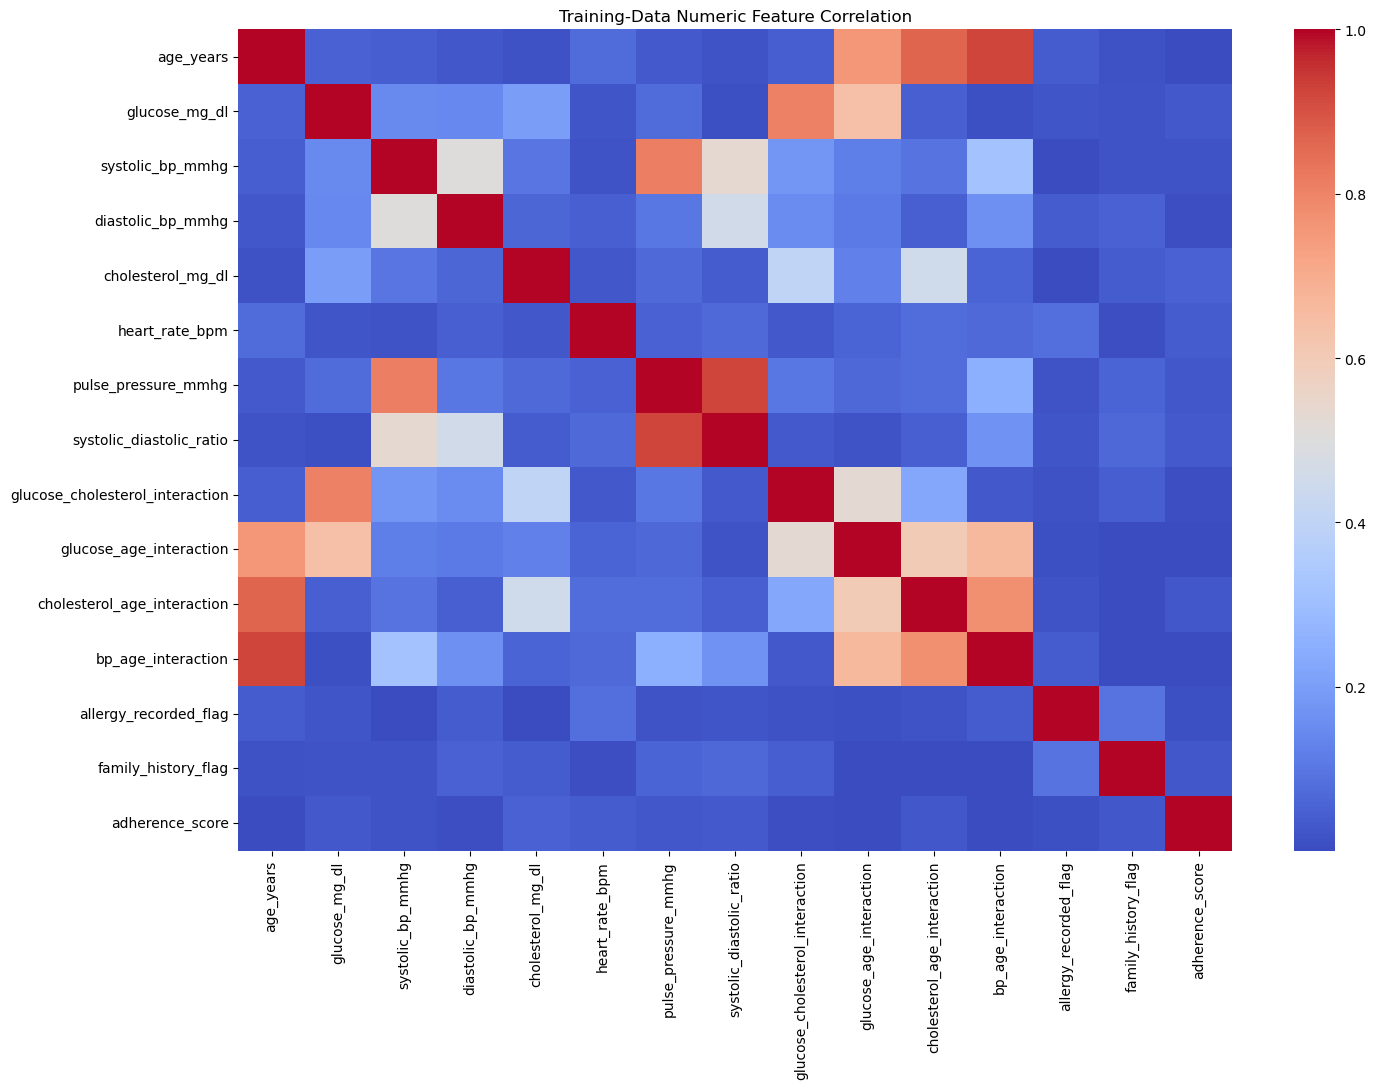

In [10]:
correlation_matrix = X_train[
    numeric_features
].corr().abs()

plt.figure(figsize=(15, 11))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    square=False
)

plt.title("Training-Data Numeric Feature Correlation")
plt.tight_layout()
plt.show()

In [11]:
upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

highly_correlated_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.95)
]

print("Highly correlated features to remove:")
print(highly_correlated_features)

Highly correlated features to remove:
[]


In [12]:
X_train_reduced = X_train.drop(
    columns=highly_correlated_features,
    errors="ignore"
).copy()

X_test_reduced = X_test.drop(
    columns=highly_correlated_features,
    errors="ignore"
).copy()

print("Before correlation reduction:", X_train.shape)
print("After correlation reduction:", X_train_reduced.shape)

Before correlation reduction: (400, 20)
After correlation reduction: (400, 20)


In [13]:
numeric_features = X_train_reduced.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train_reduced.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))

Numeric feature count: 15
Categorical feature count: 5


In [14]:
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            one_hot_encoder,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [15]:
X_train_processed = preprocessor.fit_transform(
    X_train_reduced
)

X_test_processed = preprocessor.transform(
    X_test_reduced
)

processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (400, 33)
Processed testing shape: (100, 33)


In [16]:
processed_feature_names = [
    name.replace("numeric__", "")
        .replace("categorical__", "")
    for name in processed_feature_names
]

print("Total processed features:", len(processed_feature_names))
print(processed_feature_names)

Total processed features: 33
['age_years', 'glucose_mg_dl', 'systolic_bp_mmhg', 'diastolic_bp_mmhg', 'cholesterol_mg_dl', 'heart_rate_bpm', 'pulse_pressure_mmhg', 'systolic_diastolic_ratio', 'glucose_cholesterol_interaction', 'glucose_age_interaction', 'cholesterol_age_interaction', 'bp_age_interaction', 'allergy_recorded_flag', 'family_history_flag', 'adherence_score', 'sex_Female', 'sex_Male', 'condition_Acid Reflux', 'condition_Asthma', 'condition_High Cholesterol', 'condition_Hypertension', 'condition_Seasonal Allergy', 'condition_Type 2 Diabetes', 'recorded_allergy_Latex', 'recorded_allergy_NSAID', 'recorded_allergy_None recorded', 'recorded_allergy_Penicillin', 'recorded_allergy_Sulfonamide', 'family_history_No', 'family_history_Yes', 'adherence_level_High', 'adherence_level_Low', 'adherence_level_Medium']


In [17]:
number_of_features = min(
    20,
    X_train_processed.shape[1]
)

feature_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=number_of_features
)

X_train_selected = feature_selector.fit_transform(
    X_train_processed,
    y_train
)

X_test_selected = feature_selector.transform(
    X_test_processed
)

print("Selected training shape:", X_train_selected.shape)
print("Selected testing shape:", X_test_selected.shape)

Selected training shape: (400, 20)
Selected testing shape: (100, 20)


In [18]:
feature_scores = pd.DataFrame({
    "feature": processed_feature_names,
    "mutual_information_score":
        feature_selector.scores_,
    "selected":
        feature_selector.get_support()
})

feature_scores = feature_scores.sort_values(
    "mutual_information_score",
    ascending=False
).reset_index(drop=True)

feature_scores.head(25)

,feature,mutual_information_score,selected
0,condition_Type 2 Diabetes,0.530030,True
1,condition_Seasonal Allergy,0.521898,True
2,glucose_cholesterol_interaction,0.480007,True
3,condition_High Cholesterol,0.452833,True
4,condition_Asthma,0.419973,True
5,glucose_mg_dl,0.390264,True
6,condition_Acid Reflux,0.388366,True
7,systolic_bp_mmhg,0.384100,True
8,condition_Hypertension,0.377256,True
9,cholesterol_mg_dl,0.359378,True


In [19]:
selected_feature_names = feature_scores.loc[
    feature_scores["selected"],
    "feature"
].tolist()

print("Number of selected features:")
print(len(selected_feature_names))

print("\nSelected features:")

for number, feature in enumerate(
    selected_feature_names,
    start=1
):
    print(f"{number}. {feature}")

Number of selected features:
20

Selected features:
1. condition_Type 2 Diabetes
2. condition_Seasonal Allergy
3. glucose_cholesterol_interaction
4. condition_High Cholesterol
5. condition_Asthma
6. glucose_mg_dl
7. condition_Acid Reflux
8. systolic_bp_mmhg
9. condition_Hypertension
10. cholesterol_mg_dl
11. diastolic_bp_mmhg
12. glucose_age_interaction
13. bp_age_interaction
14. cholesterol_age_interaction
15. pulse_pressure_mmhg
16. recorded_allergy_NSAID
17. allergy_recorded_flag
18. sex_Male
19. systolic_diastolic_ratio
20. recorded_allergy_Sulfonamide


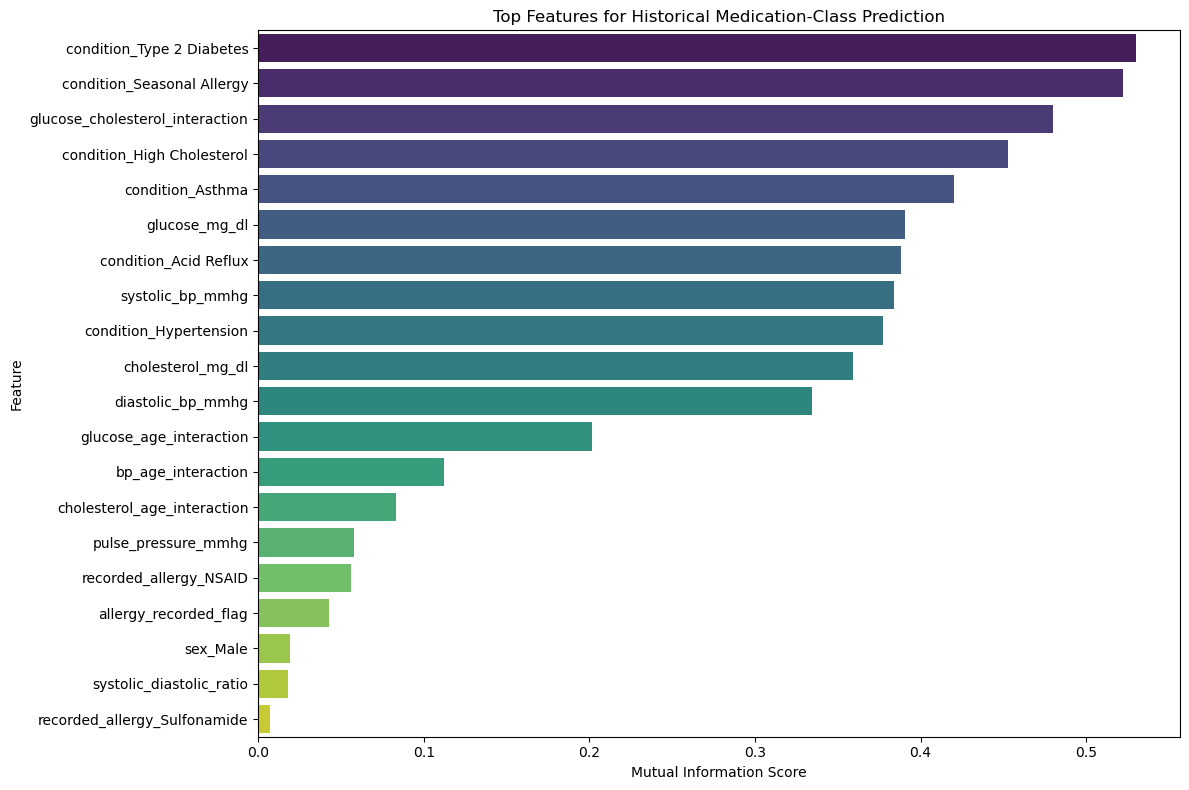

In [20]:
top_feature_scores = feature_scores.head(20)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_feature_scores,
    x="mutual_information_score",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title("Top Features for Historical Medication-Class Prediction")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [21]:
selected_feature_names_ordered = np.array(
    processed_feature_names
)[feature_selector.get_support()].tolist()

X_train_selected_df = pd.DataFrame(
    X_train_selected,
    columns=selected_feature_names_ordered,
    index=X_train_reduced.index
)

X_test_selected_df = pd.DataFrame(
    X_test_selected,
    columns=selected_feature_names_ordered,
    index=X_test_reduced.index
)

print("Selected training dataset:")
display(X_train_selected_df.head())

print("Selected testing dataset:")
display(X_test_selected_df.head())

Selected training dataset:


,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,pulse_pressure_mmhg,systolic_diastolic_ratio,glucose_cholesterol_interaction,glucose_age_interaction,cholesterol_age_interaction,bp_age_interaction,allergy_recorded_flag,sex_Male,condition_Acid Reflux,condition_Asthma,condition_High Cholesterol,condition_Hypertension,condition_Seasonal Allergy,condition_Type 2 Diabetes,recorded_allergy_NSAID,recorded_allergy_Sulfonamide
148,-0.019339,0.087701,-0.767553,-1.033326,0.623735,0.855051,-0.621140,0.792971,0.331328,1.147268,-0.523341,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
374,0.009525,-0.074208,0.328299,1.559521,-0.309069,-0.433750,1.026333,-0.027247,0.689938,-0.050072,-0.523341,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
68,-0.336849,-0.290088,0.054336,0.339358,-0.371256,-0.409076,-0.106469,0.628337,1.407158,1.103950,-0.523341,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
400,-0.365713,0.573429,-1.132837,-1.058746,1.432165,1.908994,-0.908724,0.673371,0.510633,1.691055,-0.523341,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
115,2.030040,-0.775816,0.419620,0.263098,-1.179686,-1.195885,2.331422,0.038090,-0.795407,-1.109468,-0.523341,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Selected testing dataset:


,glucose_mg_dl,systolic_bp_mmhg,diastolic_bp_mmhg,cholesterol_mg_dl,pulse_pressure_mmhg,systolic_diastolic_ratio,glucose_cholesterol_interaction,glucose_age_interaction,cholesterol_age_interaction,bp_age_interaction,allergy_recorded_flag,sex_Male,condition_Acid Reflux,condition_Asthma,condition_High Cholesterol,condition_Hypertension,condition_Seasonal Allergy,condition_Type 2 Diabetes,recorded_allergy_NSAID,recorded_allergy_Sulfonamide
48,-0.740952,-1.045665,-0.584911,-0.550344,-0.806564,-0.625429,-0.960600,-1.081496,-1.163388,-1.306712,-0.523341,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
134,2.260956,-0.721846,-1.315479,-0.041943,0.064053,0.558022,2.245497,-0.014327,-0.982310,-1.193160,-0.523341,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
93,-0.019339,-0.074208,0.602262,2.144182,-0.495630,-0.662458,1.351619,-0.323293,0.459728,-0.421008,-0.523341,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
130,0.153848,0.303580,-1.498121,2.372963,1.369978,2.117875,1.747924,-0.152753,0.695509,-0.194325,-0.523341,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
466,-0.625494,0.249610,0.419620,0.644399,0.001866,-0.196009,-0.260783,-1.267909,-1.247469,-1.432880,-0.523341,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [22]:
selection_quality = pd.DataFrame({
    "check": [
        "Original input features",
        "Processed features",
        "Selected features",
        "Training records",
        "Testing records",
        "Missing training values",
        "Missing testing values"
    ],
    "result": [
        X.shape[1],
        len(processed_feature_names),
        len(selected_feature_names_ordered),
        len(X_train_selected_df),
        len(X_test_selected_df),
        X_train_selected_df.isnull().sum().sum(),
        X_test_selected_df.isnull().sum().sum()
    ]
})

selection_quality

,check,result
0,Original input features,20
1,Processed features,33
2,Selected features,20
3,Training records,400
4,Testing records,100
5,Missing training values,0
6,Missing testing values,0


In [23]:
output_file = "selected_healthcare_features.xlsx"

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    X_train_selected_df.to_excel(
        writer,
        sheet_name="X_Train_Selected",
        index=False
    )

    X_test_selected_df.to_excel(
        writer,
        sheet_name="X_Test_Selected",
        index=False
    )

    y_train.reset_index(drop=True).to_frame(
        name=target_column
    ).to_excel(
        writer,
        sheet_name="Y_Train",
        index=False
    )

    y_test.reset_index(drop=True).to_frame(
        name=target_column
    ).to_excel(
        writer,
        sheet_name="Y_Test",
        index=False
    )

    feature_scores.to_excel(
        writer,
        sheet_name="Feature_Scores",
        index=False
    )

    selection_quality.to_excel(
        writer,
        sheet_name="Selection_Quality",
        index=False
    )

print("Feature selection completed successfully.")
print("Saved file:", output_file)

Feature selection completed successfully.
Saved file: selected_healthcare_features.xlsx
